# 05. EDA: Visualizing Data Distributions and Relationships
## 📚 Learning Objectives

By completing this notebook, you will:
- Perform exploratory data analysis (EDA) through visualization
- Visualize data distributions (histograms, box plots, density plots)
- Visualize relationships (scatter plots, correlation heatmaps)
- Discover patterns and insights
- Use Matplotlib and Seaborn effectively

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2, lessons 02-04 (the cleaned dataset) — you can only trust a chart of data you have already cleaned.

**Used later in:** Course 05 — Unit 3, which takes each chart type apart properly, and Course 06 (AIAT 116) — Unit 2, whose bias audits start from grouped distributions.

---

This notebook covers practical activities from **Course 05, Unit 2**:
- Performing EDA: Visualizing data distributions and relationships to discover insights

---

## The Story: Exploring a New City

Imagine you're exploring a new city. **Before** planning your route, you look at a map - see where things are, find interesting areas, discover connections. **After** exploring visually, you understand the city layout!

Same with data: **Before** building models, we visualize data - see distributions, find patterns, discover relationships. **After** exploring visually, we understand our data!

---

## Why EDA Visualization Matters

EDA visualization is essential because:
- **See Patterns**: Visuals reveal patterns numbers can't show
- **Detect Outliers**: Charts make outliers obvious
- **Understand Relationships**: Scatter plots show correlations
- **Communicate Insights**: Visuals are easier to understand than tables

**Common Student Questions:**
- **Q: Which chart should I use?**
  - Answer: Histogram for distributions, scatter for relationships, box plot for outliers
  - Example: Age distribution → histogram, Age vs Income → scatter plot
  - Rule: Distribution → histogram/box, Relationship → scatter/heatmap
  
- **Q: Why visualize if I have statistics?**
  - Answer: Visuals show patterns, outliers, and relationships that statistics miss
  - Example: Statistics show mean=50, but histogram shows two peaks (bimodal)
  - Benefit: Visuals reveal insights statistics can't capture

---

## Introduction

**Exploratory Data Analysis (EDA)** involves visualizing data distributions and relationships to discover patterns, anomalies, and insights. Visualization makes data exploration intuitive and reveals insights that statistics alone cannot show.


## 🎯 The case: thirteen datasets, identical statistics, and one dinosaur

In 1973 the statistician Francis Anscombe published four small datasets with the same mean,
the same variance, the same correlation and the same fitted regression line — and four
completely different pictures. In 2017 Justin Matejka and George Fitzmaurice took the idea
much further at ACM CHI, in *"Same Stats, Different Graphs"*. Using simulated annealing they
generated the **Datasaurus Dozen**: twelve datasets plus Alberto Cairo's original
dinosaur-shaped scatter, all sharing — to two decimal places — a mean x of about **54.3**, a
mean y of about **47.8**, standard deviations of about **16.8** and **26.9**, and a Pearson
correlation of about **−0.06**.

Every summary statistic a report would normally carry is identical across all thirteen. One
of them is a dinosaur. One is a circle. One is a straight slanted line. Only the plot can
tell you which dataset you have.

**What goes wrong without this lesson.** You will meet the same problem in this notebook,
on real data. `Age` and `Fare` come from the same 891 rows; `Age` has skewness **0.53** and
is roughly bell-shaped, `Fare` has skewness **4.79** and puts almost everyone in the first
bin. A single "mean fare of £32.10" is technically true of a column in which the median is
£14.45 — and only the histogram makes that visible.

*The same reasoning appears elsewhere:* John Snow mapping cholera deaths around the Broad
Street pump in 1854, where the pattern was in the geography and not in any table; and
Florence Nightingale's 1858 polar-area diagrams of British Army mortality in the Crimea,
drawn precisely because the tables had not persuaded anyone.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Clean dataset
- pandas, matplotlib, seaborn

**Outputs:** What you'll see when you run the cells

- EDA plots
- Insights

---

In [1]:
# WHAT: Import the plotting stack (pandas, NumPy, matplotlib, seaborn).
# WHY: EDA means looking at data - these four libraries generate and draw everything in this notebook.

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# WHAT: Load the real Titanic manifest and prepare the columns this notebook explores.
# WHY: EDA is about discovering what is in YOUR data - which only means something if the data was not invented to look nice.

# ============================================================================
# PART 1: THE DATA
# ============================================================================
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'
df = pd.read_csv(DATA_DIR + 'titanic.csv')

# Age has 177 genuinely missing values. Fill by (class, sex) median, as Example 2
# concluded, so the plots below are not silently dropping a fifth of the ship.
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda s: s.fillna(s.median()))
df['family_size'] = df['SibSp'] + df['Parch'] + 1

print("Real dataset loaded (Titanic passenger manifest):")
print(df[['Age', 'Fare', 'family_size', 'Pclass', 'Sex', 'Survived']].head())
print(f"\nDataset shape: {df.shape}")
print(f"Passengers: {len(df)}  |  Survivors: {int(df['Survived'].sum())}"
      f"  |  Survival rate: {df['Survived'].mean():.1%}")

# ============================================================================


----------------------------------------------------------------------
Real dataset loaded (Titanic passenger manifest):
    Age     Fare  family_size  Pclass     Sex  Survived
0  22.0   7.2500            2       3    male         0
1  38.0  71.2833            2       1  female         1
2  26.0   7.9250            1       3  female         1
3  35.0  53.1000            2       1  female         1
4  35.0   8.0500            1       3    male         0

Dataset shape: (891, 13)
Passengers: 891  |  Survivors: 342  |  Survival rate: 38.4%



PART 2: Distribution Visualizations

✅ Example 1: Histogram (Frequency Distribution)
----------------------------------------------------------------------


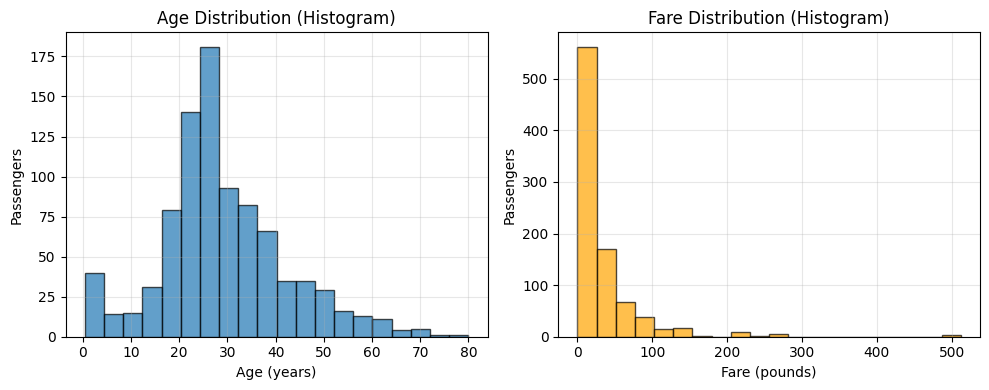

💡 Histograms show: How data is distributed, peaks, spread
   Age is roughly bell-shaped (skew 0.53), centred near 26.
   Fare is not (skew 4.79): almost everyone is in the
   first bin and a few tickets reach 512 pounds.
   Two columns from the same file, two completely different shapes.

✅ Example 2: Box Plot (Quartiles and Outliers)
----------------------------------------------------------------------


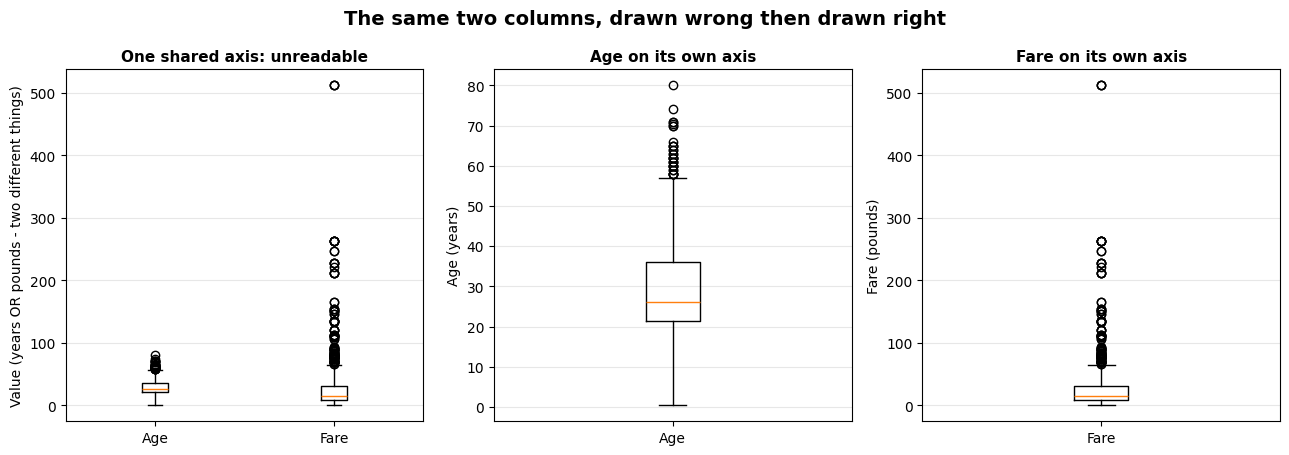

💡 Box plots show: Median, quartiles, outliers, spread
   ⚠ On the shared axis the whole Age box spans 14.5 units out
     of an axis 512 tall - about 2.8% of
     the picture. Both boxes end up crushed against the bottom and you cannot
     read Age's quartiles at all. Middle panel: Age on its own axis, instantly
     legible. Right panel: Fare barely changes - because Fare is the column
     that SET the shared axis. The cost of sharing falls entirely on the
     small-range column. Different units need different axes, or scale first
     (Example 4 in this unit).


In [3]:
# WHAT: Draw histograms and box plots of the real Age and Fare columns.
# WHY: Distribution plots answer 'what does a typical value look like, and how far do the extremes reach?'

# ============================================================================
# PART 2: DISTRIBUTION VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Distribution Visualizations")
print("=" * 70)

# Histogram
print("\n✅ Example 1: Histogram (Frequency Distribution)")
print("-" * 70)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Age (years)')
plt.ylabel('Passengers')
plt.title('Age Distribution (Histogram)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['Fare'], bins=20, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Fare (pounds)')
plt.ylabel('Passengers')
plt.title('Fare Distribution (Histogram)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("💡 Histograms show: How data is distributed, peaks, spread")
print(f"   Age is roughly bell-shaped (skew {df['Age'].skew():.2f}), centred near"
      f" {df['Age'].median():.0f}.")
print(f"   Fare is not (skew {df['Fare'].skew():.2f}): almost everyone is in the")
print(f"   first bin and a few tickets reach {df['Fare'].max():.0f} pounds.")
print("   Two columns from the same file, two completely different shapes.")

# Box Plot
print("\n✅ Example 2: Box Plot (Quartiles and Outliers)")
print("-" * 70)

# Draw the SAME two columns three ways: once sharing an axis (the mistake), then
# once each on its own axis (the fix). The comparison is the lesson.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
fig.suptitle('The same two columns, drawn wrong then drawn right',
             fontsize=14, weight='bold')

axes[0].boxplot([df['Age'], df['Fare']], tick_labels=['Age', 'Fare'])
axes[0].set_ylabel('Value (years OR pounds - two different things)')
axes[0].set_title('One shared axis: unreadable', fontsize=11, weight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].boxplot(df['Age'], tick_labels=['Age'])
axes[1].set_ylabel('Age (years)')
axes[1].set_title('Age on its own axis', fontsize=11, weight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].boxplot(df['Fare'], tick_labels=['Fare'])
axes[2].set_ylabel('Fare (pounds)')
axes[2].set_title('Fare on its own axis', fontsize=11, weight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("💡 Box plots show: Median, quartiles, outliers, spread")
age_box_height = df['Age'].quantile(0.75) - df['Age'].quantile(0.25)
axis_span = df['Fare'].max()
print(f"   ⚠ On the shared axis the whole Age box spans {age_box_height:.1f} units out")
print(f"     of an axis {axis_span:.0f} tall - about {age_box_height / axis_span:.1%} of")
print("     the picture. Both boxes end up crushed against the bottom and you cannot")
print("     read Age's quartiles at all. Middle panel: Age on its own axis, instantly")
print("     legible. Right panel: Fare barely changes - because Fare is the column")
print("     that SET the shared axis. The cost of sharing falls entirely on the")
print("     small-range column. Different units need different axes, or scale first")
print("     (Example 4 in this unit).")


**Read the figures.** *Histograms* — two columns from the same 891 rows, two completely
different shapes. `Age` (left) rises to a peak in the mid-twenties and falls away on both
sides: skew 0.53, and the word "average" means something here. `Fare` (right) puts more than
half the passengers in the very first bin and then runs out along a nearly empty axis to a
single £512 ticket: skew 4.79. Quoting "mean fare £32.10" describes almost nobody in that
picture — the median is £14.45.

*Box plots* — the left panel is the mistake, drawn on purpose. Age and Fare share one y axis
that has to reach 512 to fit the most expensive ticket, so both boxes collapse into a stripe
along the bottom. The middle panel is the same Age column on its own axis: now you can read
it — box from about 22 to 36, median at 26, whiskers out to 57, and a scatter of older
passengers above that.

Now compare the right panel with Fare's box in the left panel. They look almost identical,
and that is the real lesson: sharing an axis cost `Age` everything and cost `Fare` nothing,
because `Fare` is the column that set the axis. Whichever variable carries the biggest
numbers wins a shared axis, every time.



PART 3: Relationship Visualizations

✅ Example 3: Scatter Plot (Two Variables)
----------------------------------------------------------------------


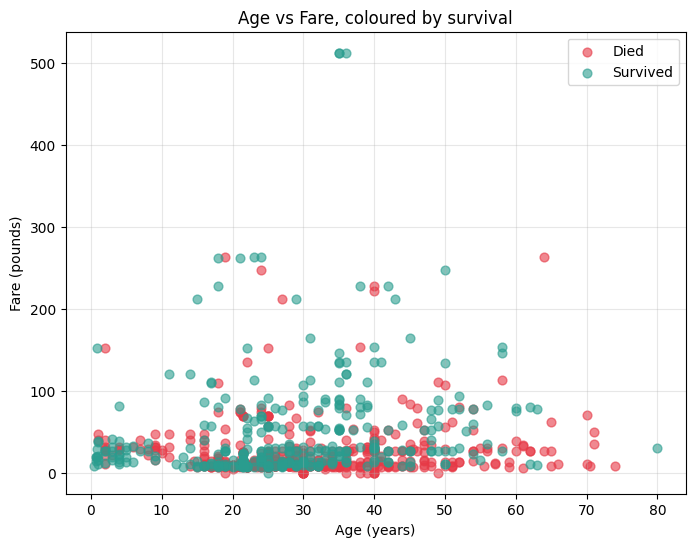

💡 Scatter plots show: Relationships, correlations, clusters
   Honest reading: Age and Fare barely move together (r = 0.12).
   Older passengers were NOT systematically richer. Real data often refuses
   to show the relationship you hoped for - report that, do not hide it.
   What the colours DO show: above 100 pounds, 53 passengers, 74% of them survived - against 38% on the ship as a whole. The top of the plot is visibly greener than the bottom.

✅ Example 4: Correlation Heatmap (Multiple Variables)
----------------------------------------------------------------------


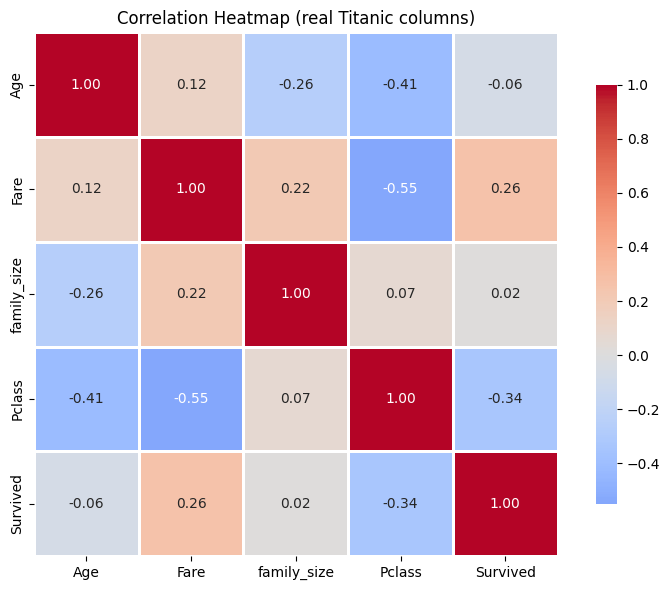

💡 Heatmaps show: Correlations between all variable pairs
   Strongest link with survival: Pclass at -0.34
   (negative because class 3 is the WORST class, not the best).
   Fare vs Pclass: -0.55 - unsurprising, they
   measure nearly the same thing. Two near-duplicate features is something
   a model will care about (Unit 4).


In [4]:
# WHAT: Explore relationships between the real numeric columns with a scatter plot and a correlation heatmap.
# WHY: Relationship plots answer 'does knowing one column tell me anything about another?' - sometimes the honest answer is no.

# ============================================================================
# PART 3: RELATIONSHIP VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Relationship Visualizations")
print("=" * 70)

# Scatter Plot
print("\n✅ Example 3: Scatter Plot (Two Variables)")
print("-" * 70)
plt.figure(figsize=(8, 6))
# Colour by survival so the scatter carries a third variable for free.
for survived, colour, label in [(0, '#E63946', 'Died'), (1, '#2A9D8F', 'Survived')]:
    subset = df[df['Survived'] == survived]
    plt.scatter(subset['Age'], subset['Fare'], alpha=0.6, s=40, c=colour, label=label)
plt.xlabel('Age (years)')
plt.ylabel('Fare (pounds)')
plt.title('Age vs Fare, coloured by survival')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
r_age_fare = df['Age'].corr(df['Fare'])
print("💡 Scatter plots show: Relationships, correlations, clusters")
print(f"   Honest reading: Age and Fare barely move together (r = {r_age_fare:.2f}).")
print("   Older passengers were NOT systematically richer. Real data often refuses")
print("   to show the relationship you hoped for - report that, do not hide it.")
high = df[df['Fare'] > 100]
print(f"   What the colours DO show: above 100 pounds, {len(high)} passengers,"
      f" {high['Survived'].mean():.0%} of them survived - against"
      f" {df['Survived'].mean():.0%} on the ship as a whole. The top of the"
      f" plot is visibly greener than the bottom.")

# Correlation Heatmap
print("\n✅ Example 4: Correlation Heatmap (Multiple Variables)")
print("-" * 70)
correlation = df[['Age', 'Fare', 'family_size', 'Pclass', 'Survived']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (real Titanic columns)')
plt.tight_layout()
plt.show()
print("💡 Heatmaps show: Correlations between all variable pairs")
print(f"   Strongest link with survival: Pclass at {correlation.loc['Pclass', 'Survived']:.2f}")
print("   (negative because class 3 is the WORST class, not the best).")
print(f"   Fare vs Pclass: {correlation.loc['Fare', 'Pclass']:.2f} - unsurprising, they")
print("   measure nearly the same thing. Two near-duplicate features is something")
print("   a model will care about (Unit 4).")


**Read the figures.** *Scatter* — each dot is one passenger, positioned by age and ticket
price and coloured by whether they survived. The cloud has no tilt to it: Pearson's r is
0.12, which is what "no linear relationship" looks like. Older passengers were not richer.
Report that; do not go hunting for a chart that says otherwise.

But look at the *colour*, not the shape. The thin band of dots above £100 is mostly teal —
"Survived" — while the dense mass along the bottom is heavily salmon. Measured under the
figure: 53 passengers paid more than £100 and 74% of them lived, against 38% for the ship. The scatter's x/y axes found nothing; its third variable
found the strongest survival signal on the page.

*Heatmap* — every pair of five columns, red for positive, blue for negative, with the value
printed in each cell. Read the `Survived` row: `Pclass` at **−0.34** is the strongest link,
negative because class 3 is the *worst* class, so a higher class number means a lower chance
of living. `Fare` at 0.26 says much the same thing in pounds. And `Fare` vs `Pclass` at
**−0.55** is the cell to worry about before modelling: those two columns are largely
measuring the same underlying fact about a passenger.



PART 4: Categorical Visualizations

✅ Example 5: Bar Plot (Categorical Data)
----------------------------------------------------------------------


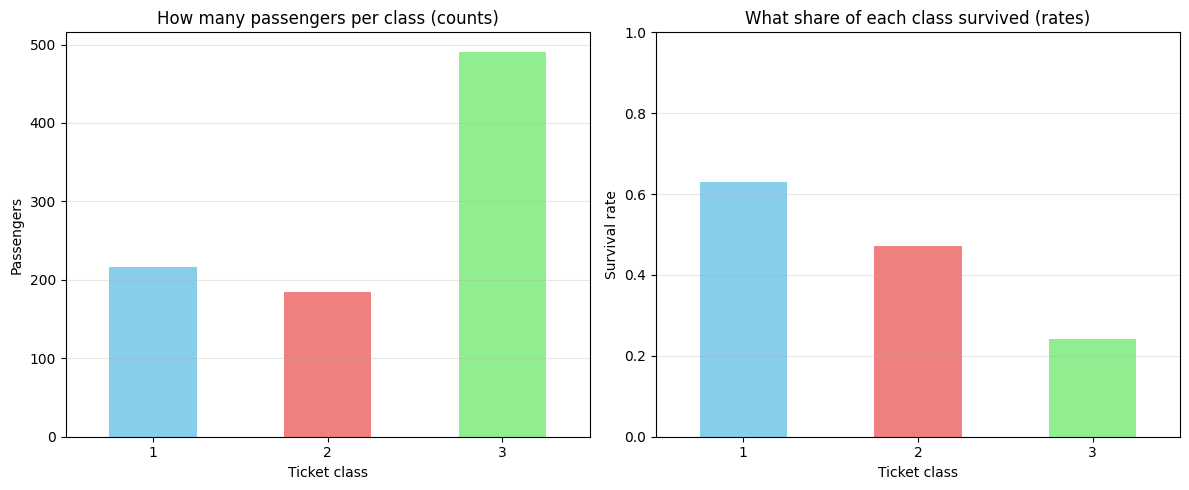

💡 Bar plots show: Counts, frequencies, comparisons
   Counts per class: {1: 216, 2: 184, 3: 491}
   Survival rate per class: {1: 0.63, 2: 0.473, 3: 0.242}
   ⚠ The two charts tell opposite stories. Class 3 had the MOST passengers
     (491) and the FEWEST survivors proportionally
     (24% vs 63% in class 1).
     Always be explicit about whether a bar is a count or a rate.

Summary

✅ What you learned:
   1. Distribution Visualizations: Histograms, box plots (understand data spread)
   2. Relationship Visualizations: Scatter plots, heatmaps (find correlations)
   3. Categorical Visualizations: Bar plots (compare categories)
   4. EDA Goals: Understand structure, find patterns, detect outliers
   5. Reporting honestly when a hoped-for relationship simply is not there

🎯 Key Takeaways:
   - Histograms: Show frequency distributions
   - Box plots: Show quartiles and outliers (mind the shared axis)
   - Scatter plots: Show relationships between variables
   - Heatmaps: Show correlations b

In [5]:
# WHAT: Compare the real categories - how many passengers per class, and what share of each class survived.
# WHY: A count bar chart and a rate bar chart answer different questions, and confusing them is a classic reporting error.

# ============================================================================
# PART 4: CATEGORICAL VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Categorical Visualizations")
print("=" * 70)

# Bar Plot
print("\n✅ Example 5: Bar Plot (Categorical Data)")
print("-" * 70)
category_counts = df['Pclass'].value_counts().sort_index()
survival_rate = df.groupby('Pclass')['Survived'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
category_counts.plot(kind='bar', ax=axes[0],
                     color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_xlabel('Ticket class')
axes[0].set_ylabel('Passengers')
axes[0].set_title('How many passengers per class (counts)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

survival_rate.plot(kind='bar', ax=axes[1],
                   color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_xlabel('Ticket class')
axes[1].set_ylabel('Survival rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('What share of each class survived (rates)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("💡 Bar plots show: Counts, frequencies, comparisons")
print("   Counts per class:", category_counts.to_dict())
print("   Survival rate per class:",
      {k: round(v, 3) for k, v in survival_rate.to_dict().items()})
print("   ⚠ The two charts tell opposite stories. Class 3 had the MOST passengers")
print(f"     ({category_counts.loc[3]}) and the FEWEST survivors proportionally")
print(f"     ({survival_rate.loc[3]:.0%} vs {survival_rate.loc[1]:.0%} in class 1).")
print("     Always be explicit about whether a bar is a count or a rate.")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Distribution Visualizations: Histograms, box plots (understand data spread)
   2. Relationship Visualizations: Scatter plots, heatmaps (find correlations)
   3. Categorical Visualizations: Bar plots (compare categories)
   4. EDA Goals: Understand structure, find patterns, detect outliers
   5. Reporting honestly when a hoped-for relationship simply is not there

🎯 Key Takeaways:
   - Histograms: Show frequency distributions
   - Box plots: Show quartiles and outliers (mind the shared axis)
   - Scatter plots: Show relationships between variables
   - Heatmaps: Show correlations between all variables
   - Bar plots: Show categorical frequencies - counts and rates are different

📚 Next Steps:
   - Example 6: Statistical EDA (complements visual EDA)
   - Unit 3: Data Visualization (more advanced techniques)
   - Use EDA insights for feature engineering
""")
print("✅ EDA visualization concepts understood!")


**Read the figure.** These two bar charts are built from the same 891 passengers and they
point in opposite directions. *Left, counts* — class 3 is by far the tallest bar at 491
passengers, more than classes 1 and 2 combined. *Right, rates* — class 3 is by far the
**shortest** bar at 24%, against 63% for class 1.

Both charts are correct. "Most of the dead were in third class" and "third class was the
most dangerous place to be" are different statements, and only the right-hand chart supports
the second one. Note also that the right axis is fixed to 0–1: a survival rate cannot exceed
1, and pinning the axis stops the difference between the classes from being exaggerated or
flattened by autoscaling. Whenever you present a bar chart, say out loud which of these two
questions it answers.


## ⚠️ Where this breaks

- **Every chart here has a knob that changes the story.** A histogram's bin width can turn
  one peak into two or hide a gap entirely; a box plot's whiskers are the 1.5×IQR
  convention from lesson 03, not a law. Change the bins, look again, and only believe a
  feature that survives.
- **A shared axis destroys the smaller variable — and the notebook shows it.** Plotting
  `Age` and `Fare` on one box-plot axis flattened Age into a line, because Fare reaches
  512. Different units need different axes or a prior scaling step.
- **Correlation is linear and Pearson's r is not robust.** `r = 0.12` for Age vs Fare rules
  out a straight-line relationship; it does not rule out a U-shape, a threshold, or a
  relationship that exists only within one class. Check Spearman's rank correlation and
  look at the scatter before concluding "no relationship".
- **The assumption that must hold: the plotted rows are the rows you care about.** This
  manifest is a subset of the people aboard, assembled from surviving records. Any pattern
  you see is a pattern in *who got recorded*, and separating the two is not something a
  chart can do for you.
- **Correlation heatmaps invite the multiple-comparisons trap.** A grid of 8 numeric
  columns is 28 correlations. At the conventional 5% level you should expect one or two to
  look "significant" from noise alone. Decide which relationships you care about *before*
  you look at the grid.
- **When plotting is the wrong first move:** on 663,522 rows, a scatter plot is a solid
  block of ink that tells you nothing — use hexbin, 2-D density, or aggregate first. And
  when the question is "is this difference real?", a chart persuades but a hypothesis test
  or a confidence interval answers; lesson 06 in this unit is where that begins.


## 💬 Discuss

Three findings from the plots above, all computed on the same 891 rows: **Age vs Fare
r = 0.12** (essentially nothing), **Pclass vs Survived r = −0.34**, and **Fare vs Pclass
r = −0.55**.

1. The notebook says plainly that older passengers were not systematically richer, and calls
   that an honest result rather than a failure. Your client hired you expecting a
   relationship there. Write the two sentences you would say in the meeting — and say what
   you would *not* do, even though it would produce a chart they like.
2. Fare and Pclass correlate at −0.55 because they measure nearly the same thing. Is that a
   problem for a *description* of the data? For a *prediction* of survival? For an
   *explanation* of why people survived? The answer differs for all three — say why.
3. The bar charts show class 3 had the **most** passengers (491) and the **worst** survival
   rate (24.2%). Those two bars point in opposite directions. Design the single chart you
   would put in front of a newspaper editor, and defend leaving out the one you dropped.


## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90-95. <https://doi.org/10.1109/MCSE.2007.55>
3. Waskom, M. L. (2021). *seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021. <https://joss.theoj.org/papers/10.21105/joss.03021>
4. Chen, N., Zhang, Y., Xu, J., Ren, K., & Yang, Y. (2024). *VisEval: A Benchmark for Data Visualization in the Era of Large Language Models*. arXiv:2407.00981. <https://arxiv.org/abs/2407.00981>
5. Zhang, S., Fan, J., Fan, M., Li, G., & Du, X. (2025). *DeepAnalyze: Agentic Large Language Models for Autonomous Data Science*. arXiv:2510.16872. <https://arxiv.org/abs/2510.16872>
